# 03 — 2D Baseline Analysis (Phase 4)

## Objective
Establish the reference result for all later comparisons: a single-slice (2D) CNN that scores LUNA16 candidates (objectness + box), evaluated with the official FROC/CPM protocol. **EXP-001-baseline-2d**, one seed (42), checkpoint chosen on validation CPM only; the test split was scored once.

## Configuration

In [1]:
from pathlib import Path
EXP = Path('../experiments/baseline/EXP-001-baseline-2d')
FIG = Path('../results/figures')

## Imports

In [2]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
import yaml
cfg = yaml.safe_load((EXP/'config.yaml').read_text())
m = json.loads((EXP/'metrics.json').read_text()); h = pd.read_csv(EXP/'history.csv')

## Setup

In [3]:
print({k: cfg[k] for k in ['data', 'model', 'training', 'loss']})
print('parameters:', m['efficiency']['parameters'], '| size MB:', round(m['efficiency']['model_size_mb'], 2))

{'data': {'input_slices': 5, 'slice_stride': 1, 'patch_size': 64, 'cache_dir': 'data/processed', 'channels': [2], 'pos_repeat': 10, 'augment': 'dihedral'}, 'model': {'attention': False, 'backbone': 'simple_cnn', 'in_channels': 1, 'widths': [16, 32, 64, 128], 'head_hidden': 64, 'dropout': 0.2}, 'training': {'batch_size': 256, 'epochs': 20, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'scheduler': 'cosine', 'selection_metric': 'val_cpm'}, 'loss': {'lambda_cls': 1.0, 'lambda_loc': 1.0, 'focal_alpha': 0.25, 'focal_gamma': 2.0}}
parameters: 302228 | size MB: 1.21


## Training curves
Training loss is `L_total = L_det = λ_cls·L_focal + λ_loc·L_loc` (both λ = 1). Validation CPM is noisy epoch to epoch (118 validation nodules: one nodule ≈ 0.85 % sensitivity), so the best epoch is a noisy pick.

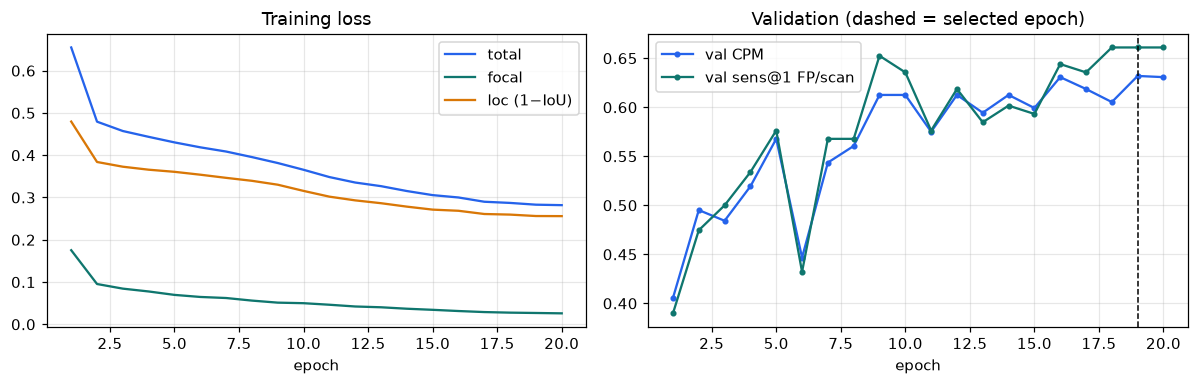

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(h.epoch, h.train_loss, label='total', color='#2563EB'); ax[0].plot(h.epoch, h.train_focal, label='focal', color='#0F766E'); ax[0].plot(h.epoch, h.train_loc, label='loc (1−IoU)', color='#D97706'); ax[0].set(xlabel='epoch', title='Training loss'); ax[0].legend()
ax[1].plot(h.epoch, h.val_cpm, color='#2563EB', marker='o', ms=3, label='val CPM'); ax[1].plot(h.epoch, h['val_sens@1'], color='#0F766E', marker='o', ms=3, label='val sens@1 FP/scan')
ax[1].axvline(m['epoch'], color='k', ls='--', lw=1); ax[1].set(xlabel='epoch', title='Validation (dashed = selected epoch)'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'EXP-001-baseline-2d_training.png'); plt.show()

## Detection performance (official LUNA16 protocol)

In [5]:
rows = []
for s in ['val', 'test']:
    d = m[s]; rows.append({'split': s, 'scans': d['n_scans'], 'nodules': d['n_nodules'], 'CPM': d['cpm'], **{f'sens@{r}': d[f'sens@{r}'] for r in [0.125, 0.25, 0.5, 1, 2, 4, 8]}, 'max sens': d['max_sensitivity'], 'random-score CPM': d['random_scores_cpm_reference']})
pd.DataFrame(rows).round(3)

,split,scans,nodules,CPM,sens@0.125,sens@0.25,sens@0.5,sens@1,sens@2,sens@4,sens@8,max sens,random-score CPM
0,val,88,118,0.632,0.381,0.508,0.576,0.661,0.703,0.763,0.831,0.958,0.007
1,test,88,105,0.675,0.400,0.476,0.648,0.695,0.771,0.857,0.876,0.962,0.005


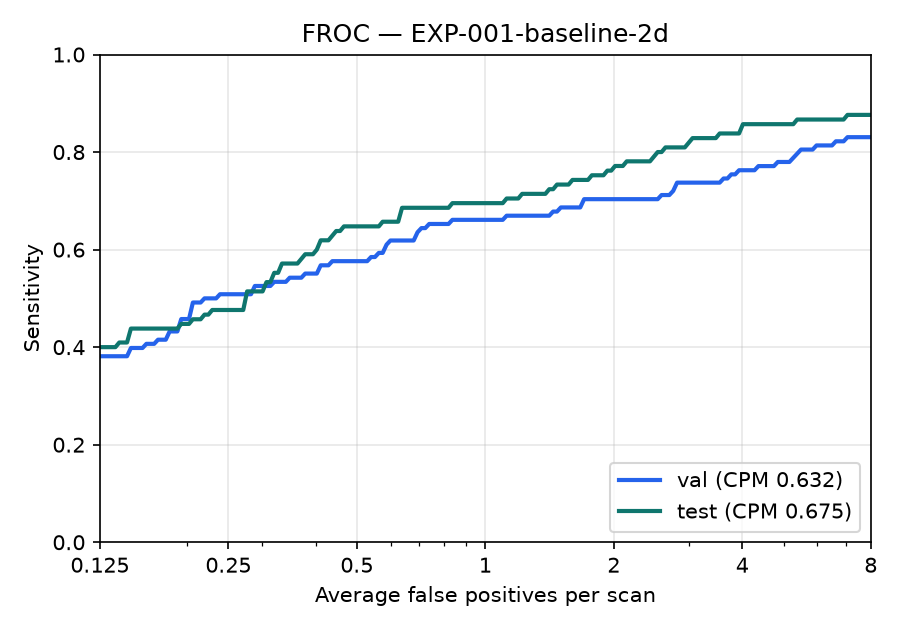

In [6]:
from IPython.display import Image; Image(str(FIG/'EXP-001-baseline-2d_froc.png'))

`max sens` is the ceiling set by the candidate list (and the official cap of 100 marks per scan): nodules without a candidate can never be detected. The random-score row is the floor (≈ 0.005).

## Efficiency (measured, documented conditions)

In [7]:
e = m['efficiency']
rows = [{'measure': 'parameters', 'value': e['parameters']}, {'measure': 'model size (MB, fp32)', 'value': round(e['model_size_mb'], 3)}, {'measure': 'sparsity', 'value': round(e['sparsity'], 5)}]
for k in [k for k in e if k.startswith('latency')]:
    rows.append({'measure': f"{k}: {e[k]['latency_ms_mean']:.2f} ± {e[k]['latency_ms_std']:.2f} ms (warm-up {e[k]['warmup']}, {e[k]['runs']} runs)", 'value': f"{e[k]['throughput_samples_per_s']:.0f} samples/s"})
pd.DataFrame(rows)

,measure,value
0,parameters,302228
1,"model size (MB, fp32)",1.209
2,sparsity,0.00009
3,latency_cpu_batch1: 1.43 ± 0.28 ms (warm-up 10...,699 samples/s
4,latency_cpu_batch256: 164.22 ± 18.43 ms (warm-...,1559 samples/s
5,latency_mps_batch256: 24.35 ± 1.10 ms (warm-up...,10515 samples/s


## Caveats and conclusions
* One training run (single seed), small validation/test sets (118 / 105 nodules): differences of a few CPM points between runs are within noise. A bootstrap confidence interval should be added before drawing conclusions from small differences.
* Test CPM (0.675) being above validation CPM (0.632) is consistent with split noise, not evidence of anything.
* This is a **candidate-scoring** baseline on the supplied LUNA16 candidates (`candidates_V2`), the standard false-positive-reduction setting of the official protocol, not a full-scan detector. FROC/CPM are the official ones (validated against the bundled example output).
* FLOPs/MACs are not yet measured (Phase 6/13).

Phase 4 gate: the 2D baseline runs end to end (dataset → training → checkpoint → prediction → evaluation).